#Setup

## Install the kagglehub library which allows loading Kaggle datasets directly into pandas


In [ ]:
!pip install kagglehub[pandas-datasets]

## Import the necessary modules from kagglehub


In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Kaggle dataset into a pandas DataFrame


In [ ]:
# Using KaggleDatasetAdapter.PANDAS ensures the dataset is returned as a pandas DataFrame
# 'path' specifies the CSV file within the dataset

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "lainguyn123/student-performance-factors",
    path="StudentPerformanceFactors.csv",
)


/tmp/ipython-input-2018664402.py:4: DeprecationWarning: load_dataset is deprecated and will be removed in a future version.
  df = kagglehub.load_dataset(


#Navigate Into Data

##Preview the first few rows of the dataset to understand its structure

In [ ]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


##Check information about the dataset:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

عدد الكولومز الرقمية 7

عدد الكولمز النصية  13

##Check for missing values in each column


In [ ]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


يوجد 3 كولومز بها ميسينج فاليو

## Check for duplicate rows in the dataset

In [ ]:
df.duplicated().sum()

np.int64(0)

لا يوجد داتا مكررة

##Explore unique values for each column


In [ ]:
for col in df.columns:
    print(f"{col}: {df[col].unique()}")

Hours_Studied: [23 19 24 29 25 17 21  9 10 14 22 15 12 20 11 13 16 18 31  8 26 28  4 35
 27 33 36 43 34  1 30  7 32  6 38  5  3  2 39 37 44]
Attendance: [ 84  64  98  89  92  88  78  94  80  97  83  82  68  60  70  75  99  74
  65  62  91  90  66  69  72  63  61  86  77  71  67  87  73  96 100  81
  95  79  85  76  93]
Parental_Involvement: ['Low' 'Medium' 'High']
Access_to_Resources: ['High' 'Medium' 'Low']
Extracurricular_Activities: ['No' 'Yes']
Sleep_Hours: [ 7  8  6 10  9  5  4]
Previous_Scores: [ 73  59  91  98  65  89  68  50  80  71  88  87  97  72  74  70  82  58
  99  84 100  75  54  90  94  51  57  66  96  93  56  52  63  79  81  69
  95  60  92  77  62  85  78  64  76  55  86  61  53  83  67]
Motivation_Level: ['Low' 'Medium' 'High']
Internet_Access: ['Yes' 'No']
Tutoring_Sessions: [0 2 1 3 4 5 6 7 8]
Family_Income: ['Low' 'Medium' 'High']
Teacher_Quality: ['Medium' 'High' 'Low' nan]
School_Type: ['Public' 'Private']
Peer_Influence: ['Positive' 'Negative' 'Neutral']
Physica

##Missing Values

In [ ]:
df.isna().sum().sum()

np.int64(235)

In [ ]:
df.notna().sum().sum()

np.int64(131905)

In [ ]:
df.isna().sum().sum()/df.notna().sum().sum()

np.float64(0.0017815852317956105)

In [ ]:
df.dropna(inplace=True)

# Prepare for MODELING : Essam Mohamed Ismail

In [ ]:
#معرفة توزيع درجات الطلاب لتحديد فئات لكل درجة
print('Score distribution:')
print(df['Exam_Score'].describe())

Score distribution:
count    6378.000000
mean       67.252117
std         3.914217
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64


درجات معظم الطلاب تتمحور بين 65 : 70


In [ ]:
# تقسيم الدرجات لفئات : عالي - متوسط - منخفض
import pandas as pd
df['Evolution']=pd.cut(
    df['Exam_Score'],
    bins=[54,65,68,104],
    labels=['Low','Medium','High'],
    include_lowest=True
    )


In [ ]:
for col in df.select_dtypes('object').columns:
    df[col] = df[col].astype('category')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6378 entries, 0 to 6606
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   Hours_Studied               6378 non-null   int64   
 1   Attendance                  6378 non-null   int64   
 2   Parental_Involvement        6378 non-null   category
 3   Access_to_Resources         6378 non-null   category
 4   Extracurricular_Activities  6378 non-null   category
 5   Sleep_Hours                 6378 non-null   int64   
 6   Previous_Scores             6378 non-null   int64   
 7   Motivation_Level            6378 non-null   category
 8   Internet_Access             6378 non-null   category
 9   Tutoring_Sessions           6378 non-null   int64   
 10  Family_Income               6378 non-null   category
 11  Teacher_Quality             6378 non-null   category
 12  School_Type                 6378 non-null   category
 13  Peer_Influence         

In [ ]:
cols=df.select_dtypes('category')
cols.columns

Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender', 'Evolution'],
      dtype='object')

In [ ]:
cols.nunique()

,0
Parental_Involvement,3
Access_to_Resources,3
Extracurricular_Activities,2
Motivation_Level,3
Internet_Access,2
Family_Income,3
Teacher_Quality,3
School_Type,2
Peer_Influence,3
Learning_Disabilities,2


In [ ]:
#تحويل كل الاعمدة الي اعمدة رقمية
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split
df_encoded = df.copy()
for col in df_encoded.select_dtypes('category').columns:
    le = LabelEncoder()
    df_encoded[col] =le.fit_transform(df_encoded[col])



In [ ]:
#ايه هو شكل الداتا و توزيعها
df_encoded.describe().T

,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6378.0,19.977109,5.985460,1.0,16.0,20.0,24.0,44.0
Attendance,6378.0,80.020853,11.550723,60.0,70.0,80.0,90.0,100.0
Parental_Involvement,6378.0,1.221856,0.865149,0.0,0.0,2.0,2.0,2.0
Access_to_Resources,6378.0,1.204453,0.870959,0.0,0.0,2.0,2.0,2.0
Extracurricular_Activities,6378.0,0.596896,0.490560,0.0,0.0,1.0,1.0,1.0
Sleep_Hours,6378.0,7.034964,1.468033,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6378.0,75.066165,14.400389,50.0,63.0,75.0,88.0,100.0
Motivation_Level,6378.0,1.307306,0.783201,0.0,1.0,2.0,2.0,2.0
Internet_Access,6378.0,0.923957,0.265087,0.0,1.0,1.0,1.0,1.0
Tutoring_Sessions,6378.0,1.495296,1.233984,0.0,1.0,1.0,2.0,8.0


Hours_Studied

المتوسط حوالي 20 ساعة (من 1 لحد 44 ساعة).

في تفاوت كبير → فيه طلبة بتذاكر قليل جدًا وأخرى كتير جدًا.

Attendance (الحضور)

متوسط الحضور حوالي %80

ده معقول، لكن فيه طلبة بيوصلوا لـ 60% بس.

Parental_Involvement & Access_to_Resources

القيم متوسطة
معناها إن الدعم الأسري والموارد مش قوي أوي عند معظم الطلبة.

Extracurricular_Activities

اكثر من النصف مشاركين في أنشطة 0.59.

Sleep_Hours

المتوسط 7 ساعات نوم، وده طبيعي وصحي.

Previous_Scores

متوسط الدرجات السابقة حوالي 75 مع تفاوت كبير (50–100).

ده مؤشر قوي على مستوى الطالب المتوقع.

Motivation_Level

متوسط التحفيز ~1.3 (على مقياس 0–2).

يعني معظمهم عندهم حافز متوسط مش عالي.

Internet_Access

أغلب الطلبة عندهم وصول للإنترنت (~92%).

Tutoring_Sessions

المتوسط حوالي 1.5 جلسة، فيه ناس بتاخد دروس خصوصية كتير (حد 8).

Family_Income & Parental_Education_Level

معظم الأسر دخلها وتعليمها متوسط (قيمة حوالي 1 على مقياس 0–2).

Learning_Disabilities

قليلة نسبيًا (~10%).

Exam_Score

متوسط الدرجة ~67 (بين 55 و101).

معظم الطلبة في نطاق 65–69 → توزيع ضيق نسبيًا.

Evolution

المتوسط ~1 (على مقياس 0–2).

يعني فيه تحسن بسيط إلى متوسط في الغالب

In [ ]:
# ايه توزيع الطلبة علي كل فئة من فئات التقييم
df['Evolution'].value_counts()

,count
Evolution,
High,2180
Medium,2152
Low,2046


تقسيم الطلبة علي المستويات متساوي تقريبا

In [ ]:
df_encoded['Evolution'].value_counts()

,count
Evolution,
0,2180
2,2152
1,2046


# Data Splitting

Splitting the data into training, validation, and test sets.

In [ ]:
# splitting for study edition
study_cols = ['Hours_Studied','Attendance','Access_to_Resources',
              'Extracurricular_Activities','Previous_Scores','Motivation_Level'
              ,'Internet_Access','Tutoring_Sessions','Teacher_Quality',
              'School_Type','Parental_Education_Level']

# ===== Classification Model school edition =====
x_sclas = df_encoded[study_cols]
y_sclas = df_encoded['Evolution']

x_sc, x_sctest, y_sc, y_sctest = train_test_split(
    x_sclas, y_sclas,
    test_size=0.2,
    random_state=42,
    stratify=y_sclas
)

x_sctrain, x_scval, y_sctrain, y_scval = train_test_split(
    x_sc, y_sc,
    test_size=0.1,
    random_state=42,
    stratify=y_sc
)
# ===== Regression Model =====
x_sreg = df_encoded[study_cols]
y_sreg = df_encoded['Exam_Score']

x_sr, x_srtest, y_sr, y_srtest = train_test_split(
    x_sreg, y_sreg,
    test_size=0.3,
    random_state=42
)
x_srtrain, x_srval, y_srtrain, y_srval = train_test_split(
    x_sr, y_sr,
    test_size=0.3,
    random_state=42)

In [ ]:
# splitting for home edition
home_cols = df_encoded.drop(columns=['Exam_Score','Evolution','Hours_Studied','Attendance','Access_to_Resources',
              'Extracurricular_Activities','Previous_Scores','Motivation_Level',
              'Internet_Access','Tutoring_Sessions','Teacher_Quality',
              'School_Type','Parental_Education_Level'], axis=1).columns




#===== Classification Model home edition =====
# x_hclas = df_encoded[['Physical_Activity','Sleep_Hours']]
x_hclas = df_encoded[home_cols]
y_hclas = df_encoded['Evolution']

x_hc, x_hctest, y_hc, y_hctest = train_test_split(
    x_hclas, y_hclas,
    test_size=0.2,
    random_state=42,
    stratify=y_hclas
)

x_hctrain, x_hcval, y_hctrain, y_hcval = train_test_split(
    x_hc, y_hc,
    test_size=0.1,
    random_state=42,
    stratify=y_hc
)
# ===== Regression Model =====
x_hreg = df_encoded[home_cols]
y_hreg = df_encoded['Exam_Score']

x_hr, x_hrtest, y_hr, y_hrtest = train_test_split(
    x_hreg, y_hreg,
    test_size=0.3,
    random_state=42
)
x_hrtrain, x_hrval, y_hrtrain, y_hrval = train_test_split(
    x_hr, y_hr,
    test_size=0.3,
    random_state=42)

In [ ]:
print("Home columns:", home_cols.tolist())
print("study columns:", study_cols)


Home columns: ['Parental_Involvement', 'Sleep_Hours', 'Family_Income', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Distance_from_Home', 'Gender']
study columns: ['Hours_Studied', 'Attendance', 'Access_to_Resources', 'Extracurricular_Activities', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Teacher_Quality', 'School_Type', 'Parental_Education_Level']


# build Models : Essam Mohammed Ismail

توقع درجات الطلاب و مستواهم بناء علي المتغيرات الدراسية و المتغيرات الحياتية


In [ ]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# تخزين اداء المودلز
class_results = {}
reg_results = {}


In [ ]:
# ===== School Classification =====
rf_sclas = RandomForestClassifier(random_state=42)
rf_sclas.fit(x_sctrain, y_sctrain)

y_pred_scval = rf_sclas.predict(x_scval)
y_pred_sctest = rf_sclas.predict(x_sctest)

In [ ]:
# ===== School Classification  Evolution =====
class_results['School Classification'] = {
    "Val Accuracy": accuracy_score(y_scval, y_pred_scval),
    "Val F1": f1_score(y_scval, y_pred_scval, average='weighted'),
    "Test Accuracy": accuracy_score(y_sctest, y_pred_sctest),
    "Test F1": f1_score(y_sctest, y_pred_sctest, average='weighted')
}


In [ ]:
# ===== School Regression =====
rf_sreg = RandomForestRegressor(random_state=42)
rf_sreg.fit(x_srtrain, y_srtrain)

y_pred_srval = rf_sreg.predict(x_srval)
y_pred_srtest = rf_sreg.predict(x_srtest)


In [ ]:
# ===== School Regression Evolution =====
reg_results['School Regression'] = {
    "Val RMSE": np.sqrt(mean_squared_error(y_srval, y_pred_srval)),
    "Val R2": r2_score(y_srval, y_pred_srval),
    "Test RMSE": np.sqrt(mean_squared_error(y_srtest, y_pred_srtest)),
    "Test R2": r2_score(y_srtest, y_pred_srtest)
}


In [ ]:
# ===== Home Classification =====
rf_hclas = RandomForestClassifier(random_state=42)
rf_hclas.fit(x_hctrain, y_hctrain)

y_pred_hcval = rf_hclas.predict(x_hcval)
y_pred_hctest = rf_hclas.predict(x_hctest)


In [ ]:
# ===== Home Classification Evolution =====
class_results['Home Classification'] = {
    "Val Accuracy": accuracy_score(y_hcval, y_pred_hcval),
    "Val F1": f1_score(y_hcval, y_pred_hcval, average='weighted'),
    "Test Accuracy": accuracy_score(y_hctest, y_pred_hctest),
    "Test F1": f1_score(y_hctest, y_pred_hctest, average='weighted')}

In [ ]:
# ===== Home Regression =====
rf_hreg = RandomForestRegressor(random_state=42)
rf_hreg.fit(x_hrtrain, y_hrtrain)

y_pred_hrval = rf_hreg.predict(x_hrval)
y_pred_hrtest = rf_hreg.predict(x_hrtest)


In [ ]:
# ===== Home Regression Evolution =====

reg_results['Home Regression'] = {
    "Val RMSE": np.sqrt(mean_squared_error(y_hrval, y_pred_hrval)),
    "Val R2": r2_score(y_hrval, y_pred_hrval),
    "Test RMSE": np.sqrt(mean_squared_error(y_hrtest, y_pred_hrtest)),
    "Test R2": r2_score(y_hrtest, y_pred_hrtest)
}


أي النماذج (المدرسية أو المنزلية) أظهرت أداء أفضل في التنبؤ سواء

 (Classification)&(Regression)،

وما الذي يمكن استنتاجه من هذه
النتائج؟

In [ ]:

class_df = pd.DataFrame(class_results).T
reg_df = pd.DataFrame(reg_results).T

print("\n===== Classification Results =====")
print(class_df)

print("\n===== Regression Results =====")
print(reg_df)



===== Classification Results =====
                       Val Accuracy    Val F1  Test Accuracy   Test F1
School Classification      0.743640  0.745710       0.757837  0.759940
Home Classification        0.360078  0.359986       0.366771  0.366617

===== Regression Results =====
                   Val RMSE    Val R2  Test RMSE   Test R2
School Regression  2.528834  0.557991   2.576916  0.565968
Home Regression    4.265437 -0.257527   4.342986 -0.232815


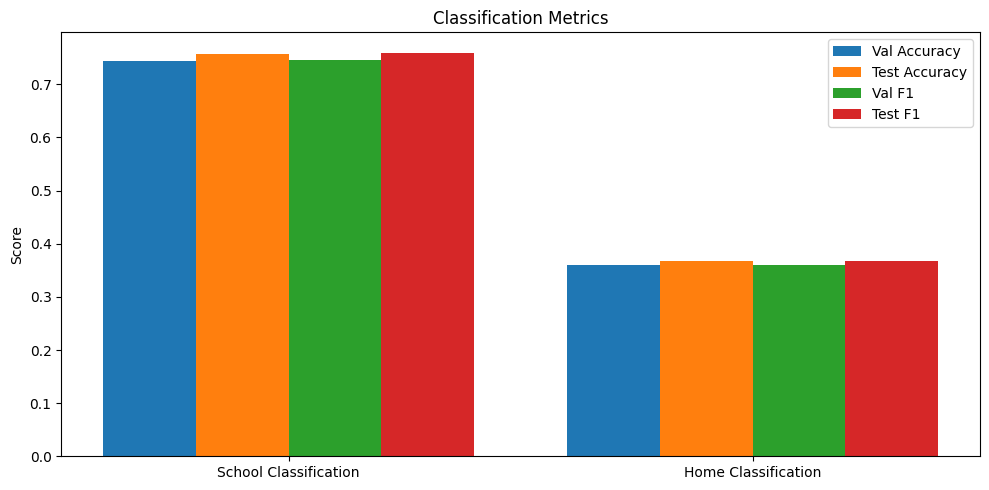

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# البيانات
class_results = {
    "School Classification": {"Val Accuracy": 0.743640, "Val F1": 0.745710, "Test Accuracy": 0.757837, "Test F1": 0.759940},
    "Home Classification": {"Val Accuracy": 0.360078, "Val F1": 0.359986, "Test Accuracy": 0.366771, "Test F1": 0.366617}
}

class_df = pd.DataFrame(class_results).T

# إعداد الرسم
metrics = ['Accuracy', 'F1']
tasks = class_df.index
n_tasks = len(tasks)
n_metrics = len(metrics)
bar_width = 0.2

x = np.arange(n_tasks)  # مواقع المهام

fig, ax = plt.subplots(figsize=(10,5))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, metric in enumerate(metrics):
    # Val Bars
    ax.bar(x + i*bar_width*2, class_df[f'Val {metric}'], width=bar_width, color=colors[i*2], label=f'Val {metric}')
    # Test Bars
    ax.bar(x + i*bar_width*2 + bar_width, class_df[f'Test {metric}'], width=bar_width, color=colors[i*2+1], label=f'Test {metric}')

# تنسيقات
ax.set_xticks(x + bar_width*1.5)
ax.set_xticklabels(tasks, rotation=0)
ax.set_ylabel('Score')
ax.set_title('Classification Metrics')
ax.legend()
plt.tight_layout()
plt.show()

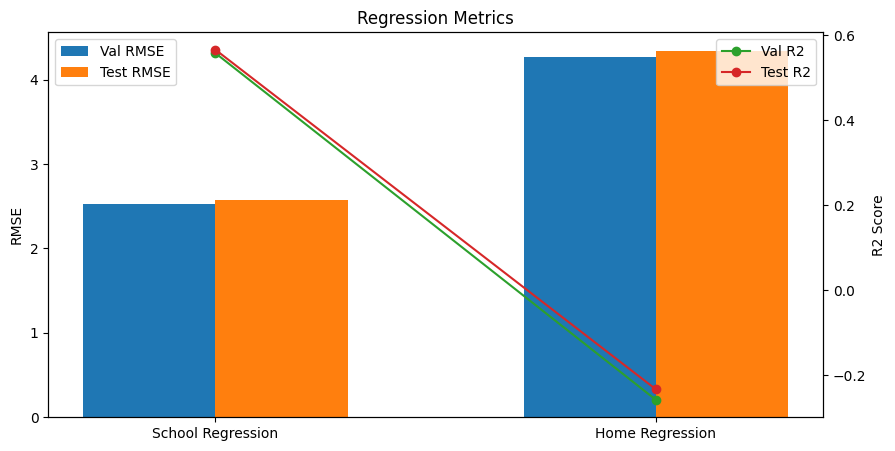

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# البيانات
reg_results = {
    "School Regression": {"Val RMSE": 2.528834, "Val R2": 0.557991, "Test RMSE": 2.576916, "Test R2": 0.565968},
    "Home Regression": {"Val RMSE": 4.265437, "Val R2": -0.257527, "Test RMSE": 4.342986, "Test R2": -0.232815}
}

reg_df = pd.DataFrame(reg_results).T

# إعداد الرسم
x = np.arange(len(reg_df))
width = 0.3

fig, ax1 = plt.subplots(figsize=(10,5))

# RMSE Bars
ax1.bar(x - width/2, reg_df['Val RMSE'], width, label='Val RMSE', color='#1f77b4')
ax1.bar(x + width/2, reg_df['Test RMSE'], width, label='Test RMSE', color='#ff7f0e')
ax1.set_ylabel('RMSE')
ax1.set_xticks(x)
ax1.set_xticklabels(reg_df.index, rotation=0)

# R2 Line
ax2 = ax1.twinx()
ax2.plot(x, reg_df['Val R2'], marker='o', color='#2ca02c', label='Val R2')
ax2.plot(x, reg_df['Test R2'], marker='o', color='#d62728', label='Test R2')
ax2.set_ylabel('R2 Score')

# Legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax1.set_title('Regression Metrics')
plt.show()

النماذج المدرسية (School Models)

 (Classification): الأداء جيد نسبيًا (دقة Val/Test حوالي 0.74–0.76 وF1 حوالي 0.75–0.76).
➝ هذا يدل على أن خصائص المدرسة (مثل الحضور، جودة المعلم، الأنشطة...) تساهم بشكل واضح في التنبؤ بتطور الطالب (Evolution).

 (Regression): الأداء متوسط جيد (Val/Test R² ≈ 0.56).
➝ يوضح أن العوامل المدرسية تفسر جزءًا معتبرًا من التباين في درجات الامتحان (Exam_Score)، لكن ليس كل التباين.

النماذج المنزلية (Home Models)

 (Classification): الأداء ضعيف جدًا (Val/Test Accuracy ≈ 0.36 وF1 ≈ 0.36).
➝ هذا يعني أن العوامل المنزلية وحدها (مثل الدخل، النوم، بُعد المنزل...) غير كافية لتحديد تطور الطالب بشكل دقيق.

 (Regression): الأداء ضعيف جدًا أيضًا (Val/Test R² ≈ -0.25 → أسوأ من التوقع المتوسط).
➝ يشير إلى أن خصائص المنزل ليس لها تأثير واضح على درجات الامتحان مقارنة بالعوامل المدرسية.

 الخلاصة

الأداء المرتفع لنماذج المدرسة مقابل ضعف نماذج المنزل يوحي بأن العوامل المدرسية (الحضور، جودة المعلم، الأنشطة...) هي المؤثر الأساسي على نجاح الطالب وتطوره أكثر من العوامل المنزلية.

# Features Visualization for Modeling



ايه هي العوامل الاكثر اهمية و تأثيرا علي كل موديل او نموذج

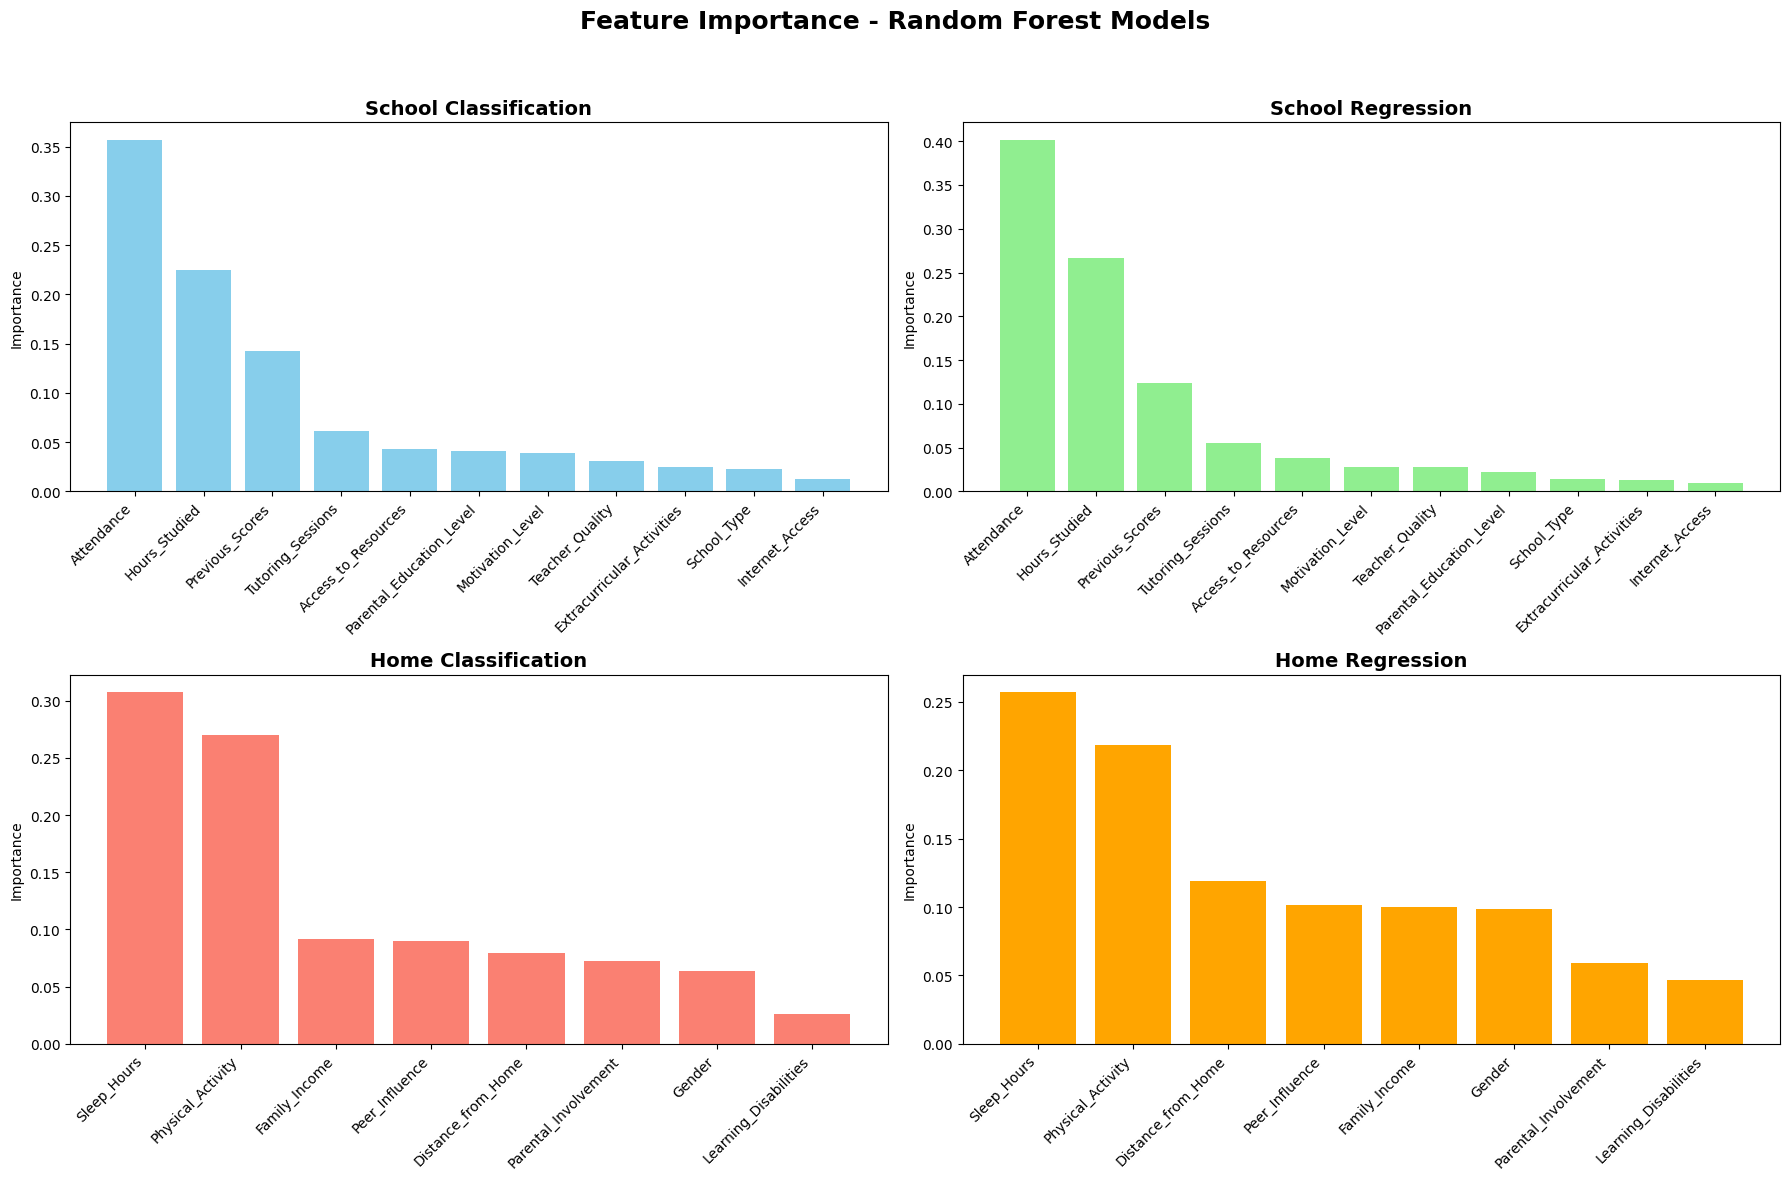

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Feature importances
feat_imp_sclas = pd.Series(rf_sclas.feature_importances_, index=x_sclas.columns).sort_values(ascending=False)
feat_imp_sreg  = pd.Series(rf_sreg.feature_importances_, index=x_sreg.columns).sort_values(ascending=False)
feat_imp_hclas = pd.Series(rf_hclas.feature_importances_, index=x_hclas.columns).sort_values(ascending=False)
feat_imp_hreg  = pd.Series(rf_hreg.feature_importances_, index=x_hreg.columns).sort_values(ascending=False)

# Plot subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Feature Importance - Random Forest Models", fontsize=18, fontweight='bold')

def plot_feat_imp(ax, feat_imp, title, color):
    ax.bar(feat_imp.index, feat_imp.values, color=color)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel("Importance")
    ax.set_xticks(range(len(feat_imp.index)))
    ax.set_xticklabels(feat_imp.index, rotation=45, ha='right', fontsize=10)

# School Classification
plot_feat_imp(axes[0,0], feat_imp_sclas, "School Classification", 'skyblue')

# School Regression
plot_feat_imp(axes[0,1], feat_imp_sreg, "School Regression", 'lightgreen')

# Home Classification
plot_feat_imp(axes[1,0], feat_imp_hclas, "Home Classification", 'salmon')

# Home Regression
plot_feat_imp(axes[1,1], feat_imp_hreg, "Home Regression", 'orange')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


لنماذج المدرسية (School Models)

أهم العوامل:

الحضور (Attendance) → له التأثير الأكبر سواء في التصنيف أو الانحدار.

عدد ساعات المذاكرة (Hours_Studied).

الدرجات السابقة (Previous_Scores).

 نجاح الطالب وتطوره الدراسي يتأثر بشكل أساسي بانتظامه في الحضور والمذاكرة، إضافة إلى أدائه السابق، بينما العوامل الأخرى (مثل جودة المعلم أو نوع المدرسة) تأثيرها أقل بكثير.

النماذج المنزلية (Home Models)

أهم العوامل:

عدد ساعات النوم (Sleep_Hours) → الأعلى تأثيرًا.

النشاط البدني (Physical_Activity).

دخل الأسرة (Family_Income) والتأثير من الأقران (Peer_Influence).

مغزى: صحة الطالب (النوم والنشاط) هي المؤثر الأبرز على أدائه، يليها البيئة الاجتماعية والاقتصادية، بينما تأثير باقي العوامل المنزلية محدود.

 الخلاصة

العوامل المدرسية (خصوصًا الحضور والمذاكرة) أكثر أهمية بكثير من العوامل المنزلية في تفسير النجاح الأكاديمي.

العوامل المنزلية الأهم ترتبط بالصحة (النوم والنشاط) أكثر من الوضع الاقتصادي أو الاجتماعي.

#EDA

###How does Hours Studied relate to Exam Score?


####The correlation is 0.45, which is a moderate positive correlation.
####Students who study more hours has higher score, but studying longer does not mean top performance.

In [ ]:
corr_hours = df["Hours_Studied"].corr(df["Exam_Score"])
corr_hours

np.float64(0.44510414026511724)

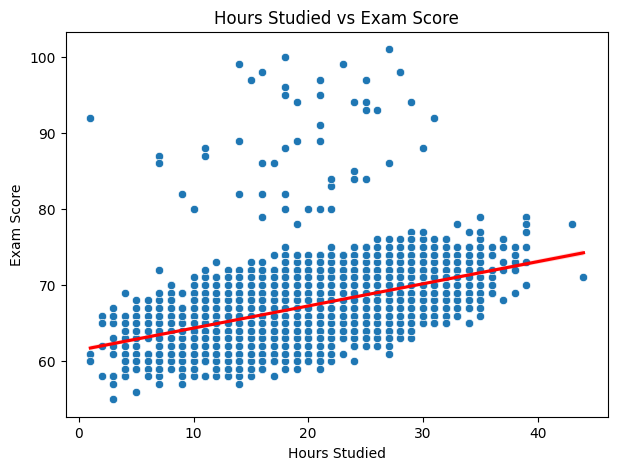

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="Hours_Studied", y="Exam_Score", data=df)
sns.regplot(x="Hours_Studied", y="Exam_Score", data=df, scatter=False, color="red")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Hours Studied vs Exam Score")

###Does higher Attendance correlate with higher Exam Score?

####The correlation between Attendance and Exam Score is moderate positive.
####Students with better attendance generally perform better on exams.

In [ ]:
corr_attendance = df["Attendance"].corr(df["Exam_Score"])
corr_attendance

np.float64(0.5802585402382593)

Text(0.5, 1.0, 'Attendance vs Exam Score')

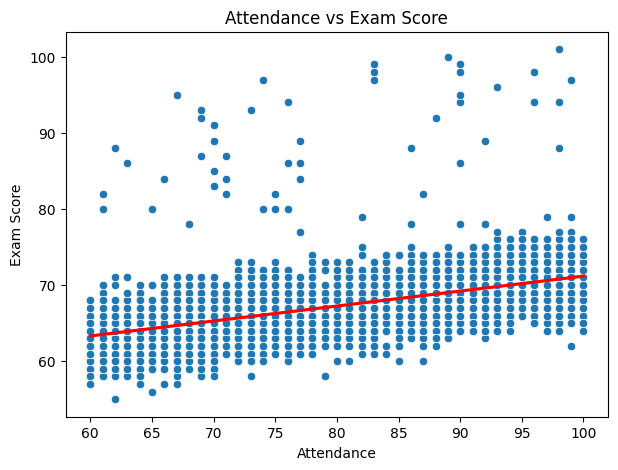

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="Attendance", y="Exam_Score", data=df)
sns.regplot(x="Attendance", y="Exam_Score", data=df, scatter=False, color="red")
plt.xlabel("Attendance")
plt.ylabel("Exam Score")
plt.title("Attendance vs Exam Score")

.###How do Parental_Involvement and Parental_Education_Level affect Exam_Score?

####Students with High parental involvement have the highest average exam scores.

####Those with Low involvement lag behind.

In [ ]:
df.groupby("Parental_Involvement")["Exam_Score"].describe()


/tmp/ipython-input-4208784509.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Parental_Involvement")["Exam_Score"].describe()


,count,mean,std,min,25%,50%,75%,max
Parental_Involvement,,,,,,,,
High,1836.0,68.112200,3.975051,57.0,66.0,68.0,70.0,100.0
Low,1291.0,66.378776,3.996295,56.0,64.0,66.0,69.0,101.0
Medium,3251.0,67.113196,3.749886,55.0,65.0,67.0,69.0,97.0


Text(0, 0.5, 'Exam Score')

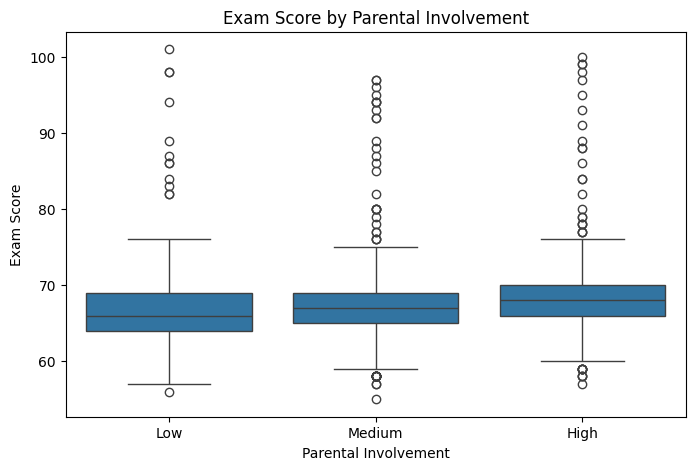

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Parental_Involvement", y="Exam_Score", data=df, order=["Low","Medium","High"])
plt.title("Exam Score by Parental Involvement")
plt.xlabel("Parental Involvement")
plt.ylabel("Exam Score")

####High School educated parents → lowest student scores on average.

####College level → higher scores.

####Postgraduate → best student performance.

In [ ]:
df.groupby("Parental_Education_Level")["Exam_Score"].describe()

/tmp/ipython-input-531821359.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Parental_Education_Level")["Exam_Score"].describe()


,count,mean,std,min,25%,50%,75%,max
Parental_Education_Level,,,,,,,,
College,1939.0,67.358432,3.841808,56.0,65.0,67.0,70.0,100.0
High School,3159.0,66.894903,3.996559,55.0,64.0,67.0,69.0,101.0
Postgraduate,1280.0,67.972656,3.706179,57.0,66.0,68.0,70.0,98.0


Text(0, 0.5, 'Exam Score')

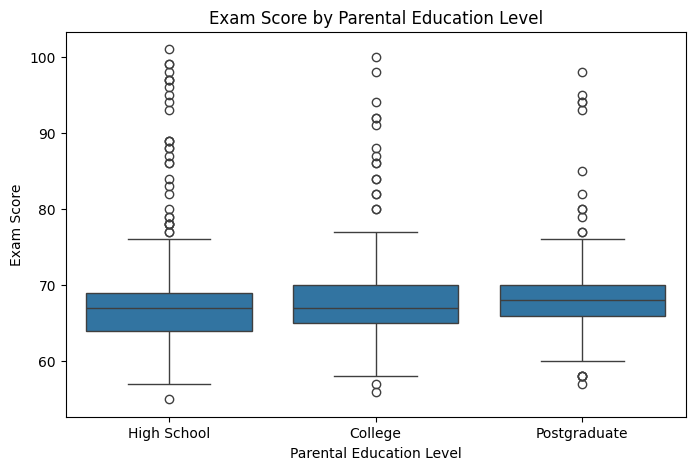

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Parental_Education_Level", y="Exam_Score", data=df,
            order=["High School","College","Postgraduate"])
plt.title("Exam Score by Parental Education Level")
plt.xlabel("Parental Education Level")
plt.ylabel("Exam Score")

###Does having Tutoring_Sessions improve performance?

####Results show that students with more tutoring sessions generally achieve higher average scores.

In [ ]:
df.groupby("Tutoring_Sessions")["Exam_Score"].describe()

,count,mean,std,min,25%,50%,75%,max
Tutoring_Sessions,,,,,,,,
0,1458.0,66.506859,3.917687,56.0,64.00,66.0,69.00,98.0
1,2111.0,66.998579,3.877936,55.0,65.00,67.0,69.00,99.0
2,1586.0,67.556747,3.876109,58.0,65.00,67.0,70.00,98.0
3,800.0,67.953750,3.638084,59.0,66.00,68.0,70.00,100.0
4,296.0,68.239865,3.671221,59.0,66.00,68.0,70.00,99.0
5,101.0,69.089109,4.823068,60.0,66.00,69.0,71.00,101.0
6,18.0,71.666667,4.200840,64.0,67.75,72.5,74.75,78.0
7,7.0,69.857143,4.099942,63.0,68.00,71.0,72.00,75.0
8,1.0,69.000000,NaN,69.0,69.00,69.0,69.00,69.0


Text(0, 0.5, 'Exam Score')

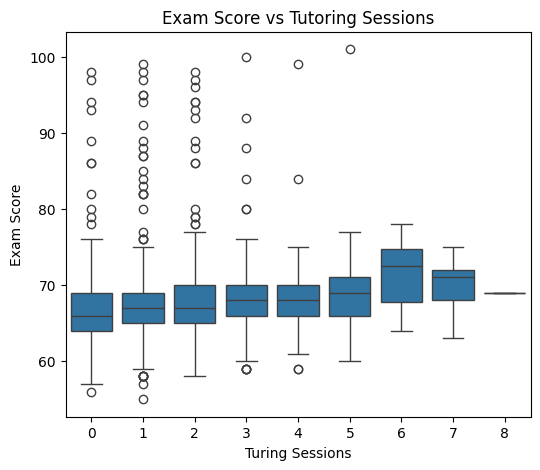

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(x="Tutoring_Sessions", y="Exam_Score", data=df)
plt.title("Exam Score vs Tutoring Sessions")
plt.xlabel("Turing Sessions")
plt.ylabel("Exam Score")